# Bengaluru House Price Regression

- **Project objective:** Predict Bengaluru house prices and evaluate predictions on the original price scale.
- **Dataset requirement:** Place `bengaluru_house_prices.csv` in the repository-root `datasets/` directory; the raw file is intentionally excluded from Git.
- **Main libraries:** pandas, NumPy, scikit-learn, Matplotlib, and Seaborn.
- **How to run:** Use Python 3.11, start Jupyter from the repository root, and run the cells in order.
- **Verified result:** Test R² 0.6996, RMSE 71.9076, and MAE 27.5162.
- **Important limitation:** Performance drops from validation to test, and this notebook is not a production-grade pricing model.

## Import the required libraries

In [1]:
import hashlib
import random
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import (
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
    VotingRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_validate
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.neural_network")
sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## Read the dataset

In [2]:
from pathlib import Path

working_directory = Path.cwd()
repository_root = working_directory.parent if working_directory.name == "ML" else working_directory
dataset_path = repository_root / "datasets" / "bengaluru_house_prices.csv"
if not dataset_path.is_file():
    raise FileNotFoundError(
        "Missing dataset. Place 'bengaluru_house_prices.csv' in the repository-root "
        "'datasets' directory, then run this notebook from the repository root or ML directory."
    )

raw_df = pd.read_csv(dataset_path)
display(raw_df.head())

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


## Understand the data

In [3]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [4]:
display(raw_df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
area_type,13320,4,Super built-up Area,8790,NaN,NaN,NaN,NaN,NaN,NaN,NaN
availability,13320,81,Ready To Move,10581,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,13319,1305,Whitefield,540,NaN,NaN,NaN,NaN,NaN,NaN,NaN
size,13304,31,2 BHK,5199,NaN,NaN,NaN,NaN,NaN,NaN,NaN
society,7818,2688,GrrvaGr,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_sqft,13320,2117,1200,843,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bath,13247.0,NaN,NaN,NaN,2.69261,1.341458,1.0,2.0,2.0,3.0,40.0
balcony,12711.0,NaN,NaN,NaN,1.584376,0.817263,0.0,1.0,2.0,2.0,3.0
price,13320.0,NaN,NaN,NaN,112.565627,148.971674,8.0,50.0,72.0,120.0,3600.0


In [5]:
print("Shape:", raw_df.shape)
print("Raw duplicated rows:", raw_df.duplicated().sum())
display(raw_df.isna().sum().to_frame("missing"))

Shape: (13320, 9)
Raw duplicated rows: 529


,missing
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


## Clean text and total square feet

Strings are normalized before duplicate checks. Normal square-foot values are kept, ranges are replaced by their mean, and supported units are converted to square feet.

In [6]:
SQFT_FACTORS = {
    "sq. meter": 10.7639,
    "sq. meters": 10.7639,
    "sq. yard": 9.0,
    "sq. yards": 9.0,
    "perch": 272.25,
    "acre": 43560.0,
    "acres": 43560.0,
    "guntha": 1089.0,
    "ground": 2400.0,
    "grounds": 2400.0,
    "cent": 435.6,
    "cents": 435.6,
}


def normalize_text(value):
    if pd.isna(value):
        return np.nan
    return re.sub(r"\s+", " ", str(value).strip().lower())


def convert_total_sqft(value):
    if pd.isna(value):
        return np.nan

    text = normalize_text(value)
    range_match = re.fullmatch(r"(\d+(?:\.\d+)?)\s*-\s*(\d+(?:\.\d+)?)", str(text))
    if range_match:
        first, second = map(float, range_match.groups())
        return (first + second) / 2

    try:
        return float(text)
    except (TypeError, ValueError):
        pass

    unit_match = re.fullmatch(r"(\d+(?:\.\d+)?)\s*([a-z. ]+)", str(text))
    if not unit_match:
        return np.nan

    amount = float(unit_match.group(1))
    unit = re.sub(r"\s+", " ", unit_match.group(2).strip())
    factor = SQFT_FACTORS.get(unit)
    return amount * factor if factor is not None else np.nan


def availability_category(value):
    if value == "ready to move":
        return "ready_to_move"
    if value == "immediate possession":
        return "immediate_possession"
    return "under_construction"


examples = pd.Series(["1200", "2100 - 2850", "100 Sq. Meter", "100 Sq. Yards", "5 Unsupported"])
display(pd.DataFrame({
    "original": examples,
    "square_feet": examples.map(convert_total_sqft),
}))

,original,square_feet
0,1200,1200.00
1,2100 - 2850,2475.00
2,100 Sq. Meter,1076.39
3,100 Sq. Yards,900.00
4,5 Unsupported,NaN


## Deterministic cleaning

The cleaning rules use raw features only. `society` has many missing values, so it is kept only as a missing-aware categorical feature for target-encoded models.

In [7]:
def stable_fingerprint(row, columns):
    parts = []
    for column in columns:
        value = row[column]
        if pd.isna(value):
            parts.append("<missing>")
        elif isinstance(value, (float, np.floating)):
            parts.append(f"{float(value):.6f}")
        else:
            parts.append(str(value))
    return hashlib.sha256("|".join(parts).encode("utf-8")).hexdigest()


data = raw_df.copy()
for column in ["area_type", "availability", "location", "size", "total_sqft", "society"]:
    data[f"{column}_clean"] = data[column].map(normalize_text)

data["bhk"] = pd.to_numeric(
    data["size_clean"].astype("string").str.extract(r"^(\d+)")[0],
    errors="coerce",
)
data["total_sqft_clean"] = data["total_sqft"].map(convert_total_sqft)
data["availability_category"] = data["availability_clean"].map(availability_category)

rows_before_deduplication = len(data)
deduplication_columns = [
    "area_type_clean", "availability_category", "location_clean", "society_clean",
    "bhk", "total_sqft_clean", "bath", "balcony", "price",
]
exact_duplicates_removed = int(data.duplicated(deduplication_columns).sum())
data = data.drop_duplicates(deduplication_columns).copy()

rows_after_deduplication = len(data)
data = data.dropna(subset=["location_clean", "bhk", "total_sqft_clean", "price"]).copy()
data = data[
    data["price"].gt(0)
    & data["bhk"].between(1, 20)
    & data["total_sqft_clean"].between(200, 50000)
].copy()

data["sqft_per_bhk"] = data["total_sqft_clean"] / data["bhk"]
data = data[data["sqft_per_bhk"] >= 250].copy()
data = data[data["bath"].isna() | ((data["bath"] >= 1) & (data["bath"] <= data["bhk"] + 3))].copy()
data = data[data["balcony"].isna() | data["balcony"].isin([0, 1, 2, 3])].copy()

fingerprint_columns = [
    "area_type_clean", "availability_category", "location_clean", "society_clean",
    "bhk", "total_sqft_clean", "bath", "balcony",
]
data["property_fingerprint"] = data.apply(stable_fingerprint, axis=1, columns=fingerprint_columns)

print("Rows after deterministic cleaning:", len(data))
print("Rows removed by feature-only checks:", rows_after_deduplication - len(data))
display(data.head())

Rows after deterministic cleaning: 12062
Rows removed by feature-only checks: 638


,area_type,availability,location,size,society,total_sqft,bath,balcony,price,area_type_clean,availability_clean,location_clean,size_clean,total_sqft_clean,society_clean,bhk,availability_category,sqft_per_bhk,property_fingerprint
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07,super built-up area,19-dec,electronic city phase ii,2 bhk,1056.0,coomee,2,under_construction,528.0,52c4c8e1d3660b0471194f79174e1ad600ad51ca11ea00...
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00,plot area,ready to move,chikka tirupathi,4 bedroom,2600.0,theanmp,4,ready_to_move,650.0,05e41c1bab7df9dbdeaffea01e9c897cb3b800b0158367...
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00,built-up area,ready to move,uttarahalli,3 bhk,1440.0,NaN,3,ready_to_move,480.0,6713b0233f4fc955e6a69503191dd5b63f623b66a87e03...
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00,super built-up area,ready to move,lingadheeranahalli,3 bhk,1521.0,soiewre,3,ready_to_move,507.0,80139acaa2089e84750403017fea9610635be3d8ac1499...
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00,super built-up area,ready to move,kothanur,2 bhk,1200.0,NaN,2,ready_to_move,600.0,147034a76ebf7f5ee25b98db7f47694d0912784b0df122...


## Add safe features

`price_per_sqft` is created only for training-data outlier analysis. It is not used as a prediction feature.

In [8]:
data["bath_missing"] = data["bath"].isna().astype(int)
data["balcony_missing"] = data["balcony"].isna().astype(int)
data["society_missing"] = data["society_clean"].isna().astype(int)
data["sqft_per_bath"] = data["total_sqft_clean"] / data["bath"].replace(0, np.nan)
data["bath_per_bhk"] = data["bath"] / data["bhk"]
data["bath_minus_bhk"] = data["bath"] - data["bhk"]
data["balcony_indicator"] = data["balcony"].fillna(0).gt(0).astype(int)
data["log_total_sqft"] = np.log1p(data["total_sqft_clean"])
data["price_per_sqft"] = data["price"] * 100000 / data["total_sqft_clean"]

model_features = [
    "location_clean", "area_type_clean", "availability_category", "society_clean",
    "total_sqft_clean", "log_total_sqft", "bhk", "bath", "balcony",
    "sqft_per_bhk", "sqft_per_bath", "bath_per_bhk", "bath_minus_bhk",
    "bath_missing", "balcony_missing", "balcony_indicator", "society_missing",
]

assert "price" not in model_features
assert "price_per_sqft" not in model_features
print("Model feature count:", len(model_features))

Model feature count: 17


## Cleaned data information and statistics

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12062 entries, 0 to 13318
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   area_type              12062 non-null  object 
 1   availability           12062 non-null  object 
 2   location               12062 non-null  object 
 3   size                   12062 non-null  object 
 4   society                7351 non-null   object 
 5   total_sqft             12062 non-null  object 
 6   bath                   12006 non-null  float64
 7   balcony                11561 non-null  float64
 8   price                  12062 non-null  float64
 9   area_type_clean        12062 non-null  object 
 10  availability_clean     12062 non-null  object 
 11  location_clean         12062 non-null  object 
 12  size_clean             12062 non-null  object 
 13  total_sqft_clean       12062 non-null  float64
 14  society_clean          7351 non-null   object 
 15  bhk    

In [10]:
display(data[[
    "price", "total_sqft_clean", "bhk", "bath", "balcony", "sqft_per_bhk"
]].describe().T)

,count,mean,std,min,25%,50%,75%,max
price,12062.0,113.576111,153.076828,8.0,50.0,70.09,120.0,3600.0
total_sqft_clean,12062.0,1613.156188,1340.875351,250.0,1114.25,1305.0,1715.0,42000.0
bhk,12062.0,2.678329,1.012644,1.0,2.0,3.0,3.0,16.0
bath,12006.0,2.586457,1.105955,1.0,2.0,2.0,3.0,16.0
balcony,11561.0,1.584033,0.815858,0.0,1.0,2.0,2.0,3.0
sqft_per_bhk,12062.0,602.087003,543.477796,250.0,488.666667,562.392917,631.5,41382.0


## Small exploratory analysis

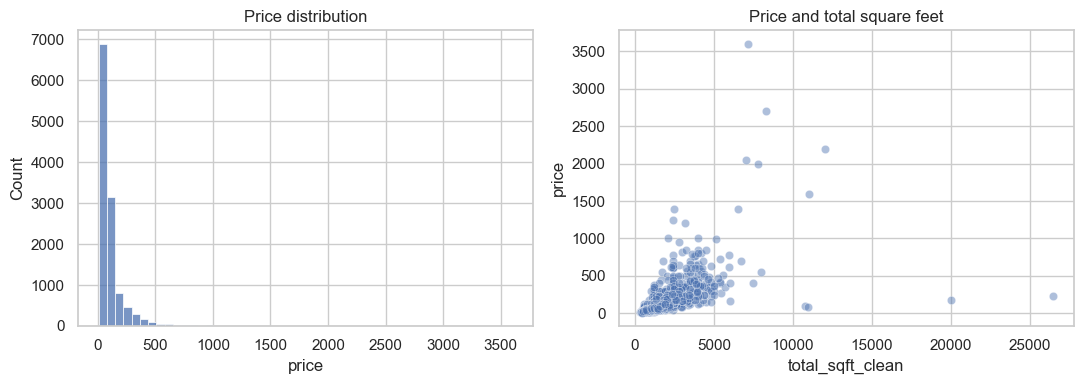

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(data=data, x="price", bins=50, ax=axes[0])
axes[0].set_title("Price distribution")

plot_sample = data.sample(min(2500, len(data)), random_state=SEED)
sns.scatterplot(data=plot_sample, x="total_sqft_clean", y="price", alpha=0.45, ax=axes[1])
axes[1].set_title("Price and total square feet")
plt.tight_layout()
plt.show()

## Locked group-aware split

The fixed seed is `42`. Records with the same property fingerprint are kept inside only one split.

In [12]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
trainval_index, test_index = next(splitter.split(
    data, data["price"], groups=data["property_fingerprint"]
))
trainval_data = data.iloc[trainval_index].copy()
test_data = data.iloc[test_index].copy()

validation_splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_relative_index, validation_relative_index = next(validation_splitter.split(
    trainval_data,
    trainval_data["price"],
    groups=trainval_data["property_fingerprint"],
))
train_data = trainval_data.iloc[train_relative_index].copy()
validation_data = trainval_data.iloc[validation_relative_index].copy()

train_fingerprints = set(train_data["property_fingerprint"])
validation_fingerprints = set(validation_data["property_fingerprint"])
test_fingerprints = set(test_data["property_fingerprint"])

train_validation_overlap = len(train_fingerprints & validation_fingerprints)
train_test_overlap = len(train_fingerprints & test_fingerprints)
validation_test_overlap = len(validation_fingerprints & test_fingerprints)

assert train_validation_overlap == 0
assert train_test_overlap == 0
assert validation_test_overlap == 0

split_audit = pd.DataFrame({
    "item": [
        "Rows before deduplication",
        "Exact duplicates removed",
        "Remaining rows",
        "Unique property fingerprints",
        "Train rows",
        "Validation rows",
        "Test rows",
        "Train/validation fingerprint overlap",
        "Train/test fingerprint overlap",
        "Validation/test fingerprint overlap",
    ],
    "value": [
        rows_before_deduplication,
        exact_duplicates_removed,
        len(data),
        data["property_fingerprint"].nunique(),
        len(train_data),
        len(validation_data),
        len(test_data),
        train_validation_overlap,
        train_test_overlap,
        validation_test_overlap,
    ],
})
display(split_audit)

,item,value
0,Rows before deduplication,13320
1,Exact duplicates removed,620
2,Remaining rows,12062
3,Unique property fingerprints,10853
4,Train rows,7671
5,Validation rows,1937
6,Test rows,2454
7,Train/validation fingerprint overlap,0
8,Train/test fingerprint overlap,0
9,Validation/test fingerprint overlap,0


## Training-only target outlier filter

The optional `price_per_sqft` filter learns boundaries from the training partition only. It is applied only to training rows. Validation and test rows are never removed using their prices.

In [13]:
def training_location_iqr_filter(frame, min_group_size=10):
    mask = pd.Series(True, index=frame.index)
    for location, group in frame.groupby("location_clean"):
        if len(group) >= min_group_size:
            q1, q3 = group["price_per_sqft"].quantile([0.25, 0.75])
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            mask.loc[group.index] = group["price_per_sqft"].between(lower, upper)
    return frame[mask].copy()


filtered_train_data = training_location_iqr_filter(train_data)
filtered_trainval_data = training_location_iqr_filter(trainval_data)

print("Training rows before filter:", len(train_data))
print("Training rows after filter:", len(filtered_train_data))
print("Training rows removed:", len(train_data) - len(filtered_train_data))

Training rows before filter: 7671
Training rows after filter: 7330
Training rows removed: 341


## Preprocessing

One candidate groups rare locations and uses one-hot encoding. The stronger candidate uses target encoding inside the training workflow, so validation and test targets are not used to learn encodings.

In [14]:
categorical_features = ["location_clean", "area_type_clean", "availability_category", "society_clean"]
numeric_features = [
    "total_sqft_clean", "log_total_sqft", "bhk", "bath", "balcony",
    "sqft_per_bhk", "sqft_per_bath", "bath_per_bhk", "bath_minus_bhk",
]
binary_features = ["bath_missing", "balcony_missing", "balcony_indicator", "society_missing"]


class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None, min_count=10):
        self.columns = columns
        self.min_count = min_count

    def fit(self, X, y=None):
        self.frequent_values_ = {}
        for column in self.columns:
            counts = X[column].value_counts(dropna=False)
            self.frequent_values_[column] = set(counts[counts >= self.min_count].index)
        return self

    def transform(self, X):
        frame = X.copy()
        for column, frequent_values in self.frequent_values_.items():
            frame[column] = frame[column].where(frame[column].isin(frequent_values), "other")
        return frame


def make_column_preprocessor(encoding="target"):
    if encoding == "target":
        categorical_encoder = TargetEncoder(target_type="continuous", cv=5, random_state=SEED)
    else:
        categorical_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

    return ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("binary", SimpleImputer(strategy="most_frequent"), binary_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
            ("encoder", categorical_encoder),
        ]), categorical_features),
    ])


def make_preprocessor(encoding="target", rare_min_count=10):
    steps = []
    if encoding == "onehot":
        steps.append(("rare_categories", RareCategoryGrouper(
            columns=["location_clean", "society_clean"], min_count=rare_min_count
        )))
    steps.append(("columns", make_column_preprocessor(encoding)))
    return Pipeline(steps)

## Compare filtering choices

In [15]:
def regression_scores(y_true, predictions):
    return {
        "r2": r2_score(y_true, predictions),
        "rmse": root_mean_squared_error(y_true, predictions),
        "mae": mean_absolute_error(y_true, predictions),
    }


def make_log_hgb_model():
    base_model = Pipeline([
        ("preprocessor", make_preprocessor("target")),
        ("model", HistGradientBoostingRegressor(
            max_iter=700,
            learning_rate=0.04,
            l2_regularization=0.10,
            max_leaf_nodes=31,
            min_samples_leaf=10,
            random_state=SEED,
        )),
    ])
    return TransformedTargetRegressor(
        regressor=base_model,
        func=np.log1p,
        inverse_func=np.expm1,
    )


filter_rows = []
for filter_name, training_frame in {
    "No target-based filter": train_data,
    "Training-only location IQR filter": filtered_train_data,
}.items():
    candidate = make_log_hgb_model()
    candidate.fit(training_frame[model_features], training_frame["price"])
    validation_predictions = candidate.predict(validation_data[model_features])
    filter_rows.append({
        "filter": filter_name,
        "train_rows": len(training_frame),
        **regression_scores(validation_data["price"], validation_predictions),
    })

filter_results = pd.DataFrame(filter_rows).sort_values("r2", ascending=False)
display(filter_results.round(4))

,filter,train_rows,r2,rmse,mae
1,Training-only location IQR filter,7330,0.8056,71.9316,28.8051
0,No target-based filter,7671,0.7880,75.1247,29.1622


## Compare regression models

Models are compared on validation data. A compact group-aware CV check is also shown for the main candidates.

In [16]:
def make_model(model_name):
    if model_name == "Linear Regression":
        return Pipeline([
            ("preprocessor", make_preprocessor("onehot", rare_min_count=20)),
            ("model", LinearRegression()),
        ])
    if model_name == "Ridge Regression":
        return Pipeline([
            ("preprocessor", make_preprocessor("onehot", rare_min_count=20)),
            ("model", Ridge(alpha=10.0)),
        ])
    if model_name == "Elastic Net":
        return Pipeline([
            ("preprocessor", make_preprocessor("onehot", rare_min_count=20)),
            ("model", ElasticNet(alpha=0.001, l1_ratio=0.2, max_iter=5000, random_state=SEED)),
        ])
    if model_name == "Random Forest":
        return Pipeline([
            ("preprocessor", make_preprocessor("target")),
            ("model", RandomForestRegressor(
                n_estimators=350, min_samples_leaf=3, max_features=0.9,
                n_jobs=1, random_state=SEED
            )),
        ])
    if model_name == "Extra Trees":
        return TransformedTargetRegressor(
            regressor=Pipeline([
                ("preprocessor", make_preprocessor("target")),
                ("model", ExtraTreesRegressor(
                    n_estimators=400, min_samples_leaf=1, max_features=1.0,
                    n_jobs=1, random_state=SEED
                )),
            ]),
            func=np.log1p,
            inverse_func=np.expm1,
        )
    if model_name == "Gradient Boosting":
        return Pipeline([
            ("preprocessor", make_preprocessor("onehot", rare_min_count=20)),
            ("model", GradientBoostingRegressor(
                n_estimators=250, learning_rate=0.04, max_depth=3,
                loss="huber", random_state=SEED
            )),
        ])
    if model_name == "HistGradientBoosting log target":
        return make_log_hgb_model()
    if model_name == "ANN log target":
        ann_regressor = Pipeline([
            ("preprocessor", make_preprocessor("onehot", rare_min_count=20)),
            ("model", MLPRegressor(
                hidden_layer_sizes=(128, 64, 32),
                activation="relu",
                solver="adam",
                alpha=0.0005,
                batch_size=64,
                learning_rate_init=0.001,
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=20,
                max_iter=300,
                random_state=SEED,
            )),
        ])
        return TransformedTargetRegressor(
            regressor=ann_regressor,
            func=np.log1p,
            inverse_func=np.expm1,
        )
    raise ValueError(model_name)


def make_blend_model():
    hgb = make_log_hgb_model()
    rf = Pipeline([
        ("preprocessor", make_preprocessor("target")),
        ("model", RandomForestRegressor(
            n_estimators=350, min_samples_leaf=3, max_features=0.9,
            n_jobs=1, random_state=SEED
        )),
    ])
    return VotingRegressor(
        estimators=[("log_hgb", hgb), ("random_forest", rf)],
        weights=[0.8, 0.2],
    )


comparison_model_names = [
    "Linear Regression",
    "Ridge Regression",
    "Elastic Net",
    "Random Forest",
    "Extra Trees",
    "Gradient Boosting",
    "HistGradientBoosting log target",
    "ANN log target",
]

selected_training_data = filtered_train_data.copy()
validation_rows = []
fitted_regressors = {}

for model_name in comparison_model_names:
    model = make_model(model_name)
    model.fit(selected_training_data[model_features], selected_training_data["price"])
    validation_predictions = model.predict(validation_data[model_features])
    validation_rows.append({
        "model": model_name,
        **regression_scores(validation_data["price"], validation_predictions),
    })
    fitted_regressors[model_name] = model

blend_model = make_blend_model()
blend_model.fit(selected_training_data[model_features], selected_training_data["price"])
blend_validation_predictions = blend_model.predict(validation_data[model_features])
validation_rows.append({
    "model": "Weighted HGB + Random Forest",
    **regression_scores(validation_data["price"], blend_validation_predictions),
})
fitted_regressors["Weighted HGB + Random Forest"] = blend_model

regression_results = pd.DataFrame(validation_rows).sort_values(
    ["r2", "rmse", "mae"], ascending=[False, True, True]
)
display(regression_results.round(4))

,model,r2,rmse,mae
8,Weighted HGB + Random Forest,0.8099,71.1418,28.5846
6,HistGradientBoosting log target,0.8056,71.9316,28.8051
4,Extra Trees,0.7650,79.0954,29.3166
3,Random Forest,0.7292,84.8969,31.1448
7,ANN log target,0.6195,100.6405,35.9019
0,Linear Regression,0.5361,111.1218,46.9343
2,Elastic Net,0.5356,111.1859,46.7337
1,Ridge Regression,0.5347,111.2877,46.7659
5,Gradient Boosting,0.4977,115.6273,39.0176


In [17]:
cv_candidates = {
    "HistGradientBoosting log target": make_log_hgb_model(),
    "Weighted HGB + Random Forest": make_blend_model(),
    "Extra Trees": make_model("Extra Trees"),
}

cv_rows = []
cv = GroupKFold(n_splits=3)
for model_name, model in cv_candidates.items():
    cv_result = cross_validate(
        model,
        selected_training_data[model_features],
        selected_training_data["price"],
        groups=selected_training_data["property_fingerprint"],
        cv=cv,
        scoring={"r2": "r2", "mae": "neg_mean_absolute_error"},
        n_jobs=1,
    )
    cv_rows.append({
        "model": model_name,
        "cv_r2_mean": cv_result["test_r2"].mean(),
        "cv_r2_std": cv_result["test_r2"].std(),
        "cv_mae_mean": -cv_result["test_mae"].mean(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values("cv_r2_mean", ascending=False)
display(cv_results.round(4))

,model,cv_r2_mean,cv_r2_std,cv_mae_mean
1,Weighted HGB + Random Forest,0.5962,0.0140,27.9758
2,Extra Trees,0.5898,0.0269,27.9856
0,HistGradientBoosting log target,0.5731,0.0090,28.6250


## Select the best validation model

The weighted HGB and Random Forest blend gives the best validation score. The final test set is still untouched at this point.

In [18]:
selected_regression_model = "Weighted HGB + Random Forest"
selected_validation_row = regression_results.loc[
    regression_results["model"].eq(selected_regression_model)
].iloc[0]

print("Best validation model:", selected_regression_model)
print("Validation R2:", f"{selected_validation_row['r2']:.4f}")
print("Validation RMSE:", f"{selected_validation_row['rmse']:.4f}")
print("Validation MAE:", f"{selected_validation_row['mae']:.4f}")

Best validation model: Weighted HGB + Random Forest
Validation R2: 0.8099
Validation RMSE: 71.1418
Validation MAE: 28.5846


## Final evaluation on the untouched test set

The model is refit on the training plus validation rows. The training-only filter is learned again from those rows only. Metrics are calculated on original-scale prices.

In [19]:
final_training_data = filtered_trainval_data.copy()
final_model = make_blend_model()
final_model.fit(final_training_data[model_features], final_training_data["price"])
final_predictions = final_model.predict(test_data[model_features])
final_scores = regression_scores(test_data["price"], final_predictions)

test_sample_count = len(test_data)
target_min = float(test_data["price"].min())
target_max = float(test_data["price"].max())

print("BEST BENGALURU MODEL:", selected_regression_model)
print("FINAL BENGALURU TEST R2:", f"{final_scores['r2']:.4f}")
print("FINAL BENGALURU TEST RMSE:", f"{final_scores['rmse']:.4f}")
print("FINAL BENGALURU TEST MAE:", f"{final_scores['mae']:.4f}")
print("FINAL BENGALURU TEST SAMPLE COUNT:", test_sample_count)
print("FINAL BENGALURU TARGET RANGE:", f"{target_min:.1f} to {target_max:.1f}")
print("Predictions and metrics use original-scale prices in lakhs.")

BEST BENGALURU MODEL: Weighted HGB + Random Forest
FINAL BENGALURU TEST R2: 0.6996
FINAL BENGALURU TEST RMSE: 71.9076
FINAL BENGALURU TEST MAE: 27.5162
FINAL BENGALURU TEST SAMPLE COUNT: 2454
FINAL BENGALURU TARGET RANGE: 10.0 to 1800.0
Predictions and metrics use original-scale prices in lakhs.


## Final plots

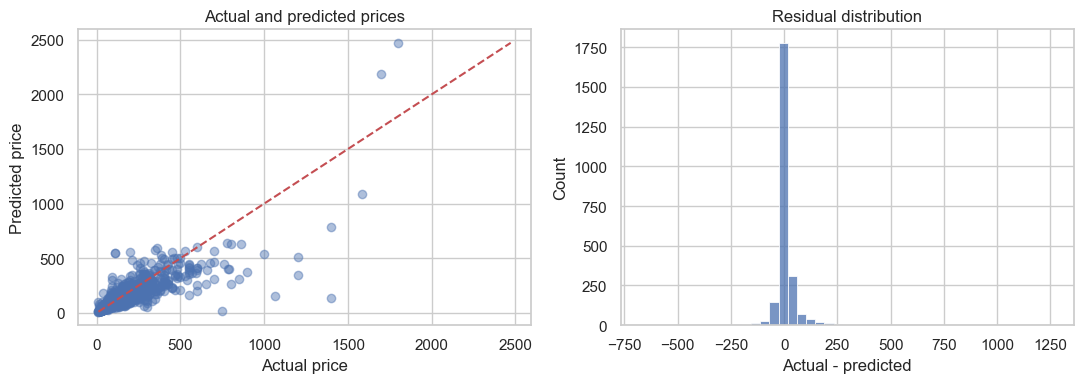

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(test_data["price"], final_predictions, alpha=0.45)
line_min = min(test_data["price"].min(), final_predictions.min())
line_max = max(test_data["price"].max(), final_predictions.max())
axes[0].plot([line_min, line_max], [line_min, line_max], "r--")
axes[0].set_title("Actual and predicted prices")
axes[0].set_xlabel("Actual price")
axes[0].set_ylabel("Predicted price")

residuals = test_data["price"].to_numpy() - final_predictions
sns.histplot(residuals, bins=45, ax=axes[1])
axes[1].set_title("Residual distribution")
axes[1].set_xlabel("Actual - predicted")
plt.tight_layout()
plt.show()

## Conclusion

Duplicate leakage was removed with a grouped split and zero-overlap assertions. The final Bengaluru result is reported honestly on original-scale prices, but it does not reach the required R2 target.